# FLAIR-FST: Lexicon building tools for language revitalization

This notebook contains an overview of the FLAIR WFST tools and their usage, including an introduction to WFSTs.

## Introduction

Some basic questions:

- What is a (W)FST?
- What is it good for?
- I'm sold!  How do I make one and how to I use it?

### Setup

Let's start by importing the `FST` and `Paradigm` classes from the `pyfoma` library that our tools are based on:

In [1]:
from pyfoma import FST, Paradigm

### What is a FST?

You can read the [technical and formal definition](https://en.wikipedia.org/wiki/Finite-state_transducer), but for our purposes, it's most useful to think of an FST as a kind of dictionary.  That is, it is a particular way for a computer to represent a collection of pairs of words.  An FST (finite-state transducer) is a particular case of a finite-state machine (no, not [that](https://en.wikipedia.org/wiki/Flying_Spaghetti_Monster) kind of FSM).  There is also a simpler form of FST which we refer to as an *acceptor* or FSA.  In this case, it's also like a dictionary except that it is just a collection of individual words.  When you add the "W" to it to get a *weighted* FST, it represents not just a collection of pairs of words, but also a numerical value associated with each pair of words.  We aren't going to talk about that much here, but keep it in mind for later.

That's all very abstract, so how exactly does it represent words?  Well, the vocabulary is defined by all of the possible *paths* through a network of *states* (a finite number of them, hence the name) connected by *arcs* which are "labeled" with individual letters (or pairs of letters).  Let's look at a simple acceptor with a vocabulary of four words:

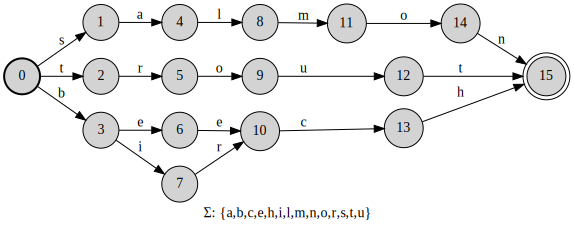

In [2]:
fsa = FST.from_strings(["salmon", "trout", "birch", "beech"])
fsa.view()

Imagine that you are walking, skiing or snowshoeing through a forest, or perhaps running an orienteering or adventure race, where there are a lot of trails which sometimes cross each other, branch apart and come back together.  Your goal is to get from the start (marked with 0 here) to the end (marked with two circles) by following any of the trails.  Like a lot of trail systems, each path has a letter that identifies it, so you can describe your route by putting these letters together in the order you follow them, for example s-a-l-m-o-n or b-i-r-c-h.

(You could also describe the sequence of states, which is equivalent, but for various reasons it's more common to use the arcs)

The "language" of the FSA is all of the possible paths you could take:

In [3]:
from flair_fst import pairs

[a for a, _ in pairs(fsa)]

['trout', 'beech', 'birch', 'salmon']

And, it can also tell you what paths you *can't* take:

In [4]:
list(fsa.apply("spruce"))

[]

Now let's consider an FST, which, as mentioned earlier, is exactly the same thing, except that each path is marked with *two* letters instead of one, and so the language is a set of *pairs*.  For example, we could imagine an FST for an English-French dictionary:

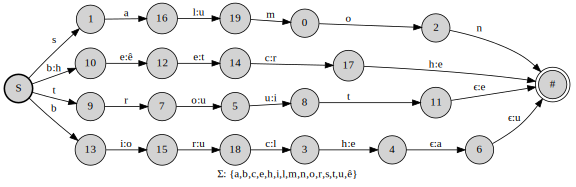

In [5]:
fst = FST.rlg(
    {
        "S": [
            (("salmon", "saumon"), "#"),
            (("trout", "truite"), "#"),
            (("birch", "bouleau"), "#"),
            (("beech", "hêtre"), "#"),
        ]
    },
    "S",
)
fst.view()

You may notice these strange ϵ symbols in various places - these are a special symbol which means "nothing", in other words, that at this point in the path, there is a letter on one side, and nothing on the other.  Also, in the case where there's just a single letter on the path, it means that both sides are the same letter.

What can we do with this?  We can, obviously, print out all of the pairs of words that it recognizes:

In [6]:
print(Paradigm(fst, ".*"))

beech     hêtre    
birch     bouleau  
salmon    saumon   
trout     truite   



But more interestingly, it also works as a *mapping* from one word to the other in each pair, so in this case you can use it to *translate* words, just like looking up in a dictionary, and more importantly, this works in both directions (looking up English to get French, or French to get English):

In [7]:
list(fst.apply("beech"))

['hêtre']

In [8]:
list(fst.analyze("hêtre"))

['beech']

### What is it good for?

Spolier alert: somewhat more than absolutely nothing!

The "translation" example above isn't particularly realistic (that's not how machine translation works), but what is realistic is using an FSA to store a list of words, or an FST to store a mapping of a list of words to the *pronunciation* of each word.  This is very useful for speech recognition, or for second language education, for instance!  For example:

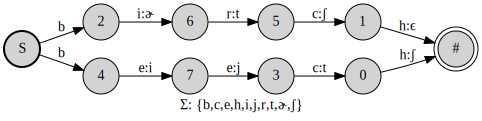

In [9]:
fst = FST.rlg(
    {
        "S": [
            (("birch", "bɚtʃ"), "#"),
            (("beech", "bijtʃ"), "#"),
        ]
    },
    "S",
)
fst.view()

(you'll notice that the FST doesn't necessary make "logical" choices of which letters to map to which IPA symbols, because it doesn't actually know anything about phonology)

Why would you do this instead of just storing this list or mapping in your favorite data structure in your favorite programming language?  Or, you know, on paper, like the good old days?

This is where it gets a bit confusing.  Even though it's "finite-state", an FST can actually represent, with its finite states, an *infinite* number of different (pairs of) words.  And as all good linguists know, human languges generally contain an infinite (or at least extremely large) number of possible words, because humans are good at:

- inventing new words based on existing words and well-known patterns or rules (*derivation*)
- recognizing a large number of words as actualy being the "same" word, just in a different context, tense, person, etc, etc (*conjugation*, *declension*, or as linguists say, *inflection*)

And as *you* probably know, polysynthetic languages, like most of the Indigenous languages of the Americas, have a particularly large number of words that are not only possible, but commonly used.

So this brings us to the most important reason we want to make an FST in this project: in order to be able to make a dictionary for a language, without having to make a list of all of the possible words, since:

1. we don't have that list, **and**
2. that list is incredibly long, **but**
3. we *do* know something about how people who speak that language *make* words.

So, for a final, more realistic example, let's see how that works for a definitely not polysynthetic language, but one where we know how to make words.  Let's conjugate some French verbs (badly).  Note that we're going to forget about pronunciation here and just use the spelling for the moment.

In [10]:
rlg = {
    "V": [
        (("parler", "parl"), "ErInfl"),
        (("marcher", "march"), "ErInfl"),
        (("gagner", "gagn"), "ErInfl"),
    ],
    "ErInfl": [
        (("+inf", "+er"), "#"),
        (("+pres+1sg", "+es"), "#"),
        (("+pres+2sg", "+es"), "#"),
        (("+pres+3sg", "+e"), "#"),
        (("+pres+1pl", "+ons"), "#"),
        (("+pres+2pl", "+ez"), "#"),
        (("+pres+3pl", "+ent"), "#"),
    ],
}
lex = FST.rlg(rlg, "V")
print(Paradigm(lex, ".*"))

gagner+inf          gagn+er    
gagner+pres+1pl     gagn+ons   
gagner+pres+1sg     gagn+es    
gagner+pres+2pl     gagn+ez    
gagner+pres+2sg     gagn+es    
gagner+pres+3pl     gagn+ent   
gagner+pres+3sg     gagn+e     
marcher+inf         march+er   
marcher+pres+1pl    march+ons  
marcher+pres+1sg    march+es   
marcher+pres+2pl    march+ez   
marcher+pres+2sg    march+es   
marcher+pres+3pl    march+ent  
marcher+pres+3sg    march+e    
parler+inf          parl+er    
parler+pres+1pl     parl+ons   
parler+pres+1sg     parl+es    
parler+pres+2pl     parl+ez    
parler+pres+2sg     parl+es    
parler+pres+3pl     parl+ent   
parler+pres+3sg     parl+e     



What did we just do?  Well, we started with 3 root words and 7 endings, and we turned this into 21 words.  Every time we add another root word, we get 7 more words that the FST can recognize... and over time this number can get very, very large.

Of course this isn't the whole story, because making words isn't that simple.  What if we add sneaky words like "manger" and "placer" to the roots?

In [11]:
rlg["V"].append((("manger", "mang"), "ErInfl"))
rlg["V"].append((("placer", "plac"), "ErInfl"))
lex = FST.rlg(rlg, "V")
print(Paradigm(lex, "mang.*"))
print(Paradigm(lex, "plac.*"))

manger+inf         mang+er   
manger+pres+1pl    mang+ons  
manger+pres+1sg    mang+es   
manger+pres+2pl    mang+ez   
manger+pres+2sg    mang+es   
manger+pres+3pl    mang+ent  
manger+pres+3sg    mang+e    

placer+inf         plac+er   
placer+pres+1pl    plac+ons  
placer+pres+1sg    plac+es   
placer+pres+2pl    plac+ez   
placer+pres+2sg    plac+es   
placer+pres+3pl    plac+ent  
placer+pres+3sg    plac+e    



French speakers will notice right away (or not) that this is wrong, because the first person plural form of "manger" is not "mangons" but actually "mangeons", and likewise, it's not "placons" but "plaçons".  Also what's up with all those `+` symbols everywhere?  Can we get rid of them?

Yes, we can, and how will we do that?  More FSTs of course!  Because the useful thing about FSTs is not just that they store pairs of words efficiently, but as mentioned earlier, they can represent a *mapping* between pairs of words, and this mapping can be something like:

- All of the words in the language, with each word mapped to the same word without any `+` symbols
- All of the words in the language, with `g+o` mapped to `g+eo` and `c+o` mapped to `ç+o`

And there's a weird trick (actually a well-defined algorithm) which allows you to take an FST and then apply (we say "compose") another FST to it, and then another FST to it, and so on.  This means we can make an FST that represents:

- All our verbs, conjugated in the present tense, **then**
- With spelling rules applied to the stems like we did above, **then**
- With those pesky `+` symbols out of the picture.

Let's see what that looks like (we have to add some parentheses and backslashes...):

In [12]:
no_plus = FST.regex(r"$^rewrite( \+:'' )")
list(no_plus.apply("blah blah blah g+o blah c+o blah"))

['blah blah blah go blah co blah']

In [13]:
go_geo = FST.regex(r"$^rewrite( (g\+o) : (ge\+o) | (c\+o) : (ç\+o) )")
list(go_geo.apply("blah blah blah g+o blah c+o blah"))

['blah blah blah ge+o blah ç+o blah']

Now let's put them together!

In [14]:
from pyfoma.algorithms import compose

go_geo_no_plus = compose(go_geo, no_plus)
list(go_geo_no_plus.apply("blah blah blah g+o blah c+o blah"))

['blah blah blah geo blah ço blah']

And now ... we can do that with the lexicon, and see what we get.

In [15]:
lex_fixed = compose(lex, go_geo_no_plus)
print(Paradigm(lex_fixed, "mang.*"))
print(Paradigm(lex_fixed, "plac.*"))

manger+inf         manger    
manger+pres+1pl    mangeons  
manger+pres+1sg    manges    
manger+pres+2pl    mangez    
manger+pres+2sg    manges    
manger+pres+3pl    mangent   
manger+pres+3sg    mange     

placer+inf         placer   
placer+pres+1pl    plaçons  
placer+pres+1sg    places   
placer+pres+2pl    placez   
placer+pres+2sg    places   
placer+pres+3pl    placent  
placer+pres+3sg    place    



And note that we can not only use this to dictionary lookup, but we also get *morphological analysis* along with that lookup:

In [16]:
list(lex_fixed.analyze("mangeons"))

['manger+pres+1pl']

Of course, we can do a lot more than that, for example, the spelling rules above are obviously really incomplete, since the alternation happens before all vowels except `e` and `i` (and really, we might want to represent it in a totally different way, but in any case...).  Instead of listing all of the possibilities, we can use a *context* for the alternation:

In [17]:
speling_rule = FST.regex(r"$^rewrite( g:(ge) | c:ç / _ \+ [aou] )")
list(speling_rule.apply("g+i g+o g+a c+e c+o c+u c+a"))

['g+i ge+o ge+a c+e ç+o ç+u ç+a']

There are some important limits to what this kind of rule can do in an FST.  The most important thing to remember is that a rule applies to every possible context in the input at once, and (somewhat obviously) will not recognize its own output in the context.  This means that in many cases the result of applying a rule is ambiguous, and so, for instance, using `list(rule.apply(input))` you will get multiple outputs.

Another important limitation is that there is no way to copy from the input or the context to the output of a rule.  Computer programmers may recognize the mini-language used by `FST.regex` as being superficially similar to the mini-language used by "regular expressions" in Python, Javascript, etc, but in order for composition (and other `pyfoma.algorithms`) to work, it is actually much more limited in what it can express.

In particular, `$^rewrite` is **not** the same thing as `re.sub` and most importantly has no ability to "capture" and copy text from the input or context to the output!  So for instance you can't do this with an FST:

In [18]:
import re

re.sub(r"_([^_]+)_", r"<u>\1</u>", "Let's _underline_ some arb_it_rary t_ext_!")

"Let's <u>underline</u> some arb<u>it</u>rary t<u>ext</u>!"

You can find more information about rules in [the Pyfoma documentation](https://github.com/mhulden/pyfoma/blob/main/docs/examples/RegularExpressionCompiler.ipynb).

## I'm sold!

Great, sign here!  Let's look at what the FLAIR FST tools can do for you, then.

### How do I make one?

As you might have noticed above, the `pyfoma` library is incredibly flexible, but requires you to write all sorts of arcane incantations to actually define your FST.  We have simplified this considerably in order to support what we think is the process that will produce something immediately useful, while allowing the community and linguists to progressively enhance it to recognize more and more words over time.

### How do I use it?

Once you have compiled your FST, you will have a JSON file, that you can "run" with the Javascipt runtime in your browser.